<a href="https://colab.research.google.com/github/PaolinaCastany/Master_Thesis/blob/main/ThesisPart3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pickle
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the base folder path in Google Drive
# !!! IMPORTANT: Replace with the actual path to your base folder if it's different !!!
BASE_FOLDER = '/content/drive/MyDrive/Thesis_Music_Success'

# Define folder structure using the base folder
FOLDERS = {
    'data': os.path.join(BASE_FOLDER, 'data'),
    'plots': os.path.join(BASE_FOLDER, 'plots'),
    'models': os.path.join(BASE_FOLDER, 'models'),
    'results': os.path.join(BASE_FOLDER, 'results')
}

# Verify base folder exists (optional, but good practice)
if not os.path.exists(BASE_FOLDER):
    print(f"❌ Error: Base folder not found at {BASE_FOLDER}")
    print("Please check the BASE_FOLDER path and ensure Google Drive is mounted.")
else:
    # Save folder paths for later use in /content/
    FOLDERS_FILE_PATH = '/content/folders.pkl'
    with open(FOLDERS_FILE_PATH, 'wb') as f:
        pickle.dump(FOLDERS, f)
    print(f"✓ Folder paths saved to {FOLDERS_FILE_PATH}")
    print("Please ensure the paths within folders.pkl are correct and the corresponding directories exist in Google Drive.")

Mounted at /content/drive
✓ Folder paths saved to /content/folders.pkl
Please ensure the paths within folders.pkl are correct and the corresponding directories exist in Google Drive.


GENRE-SPECIFIC MODELS TRAINING
Author: Paolina CASTANY
Date: 2025-10-25 07:42

1. LOADING DATA

✓ Data loaded:
   Train: 133,496 tracks
   Test: 34,798 tracks
   Features: 13
   Genres: 8

   Selected genres: black-metal, gospel, ambient, acoustic, alt-rock, emo, indian, k-pop

2. TRAINING GENRE-SPECIFIC REGRESSION MODELS

GENRE: BLACK-METAL

📊 Data:
   Train: 17,253 tracks
   Test:  4,584 tracks
   Popularity:
      Train - Mean: 9.95, Std: 8.28
      Test  - Mean: 15.33, Std: 8.39

🌳 Training Random Forest Regressor...

✓ Results:
   MAE:  7.4280
   RMSE: 9.8153
   R²:   -0.3681

   Top 5 Features:
      danceability        : 0.1357
      loudness            : 0.1099
      acousticness        : 0.0982
      duration_mins       : 0.0944
      speechiness         : 0.0899
✓ Saved model: rf_regression_black_metal.pkl
✓ Saved: feature_importance_reg_black_metal.csv

GENRE: GOSPEL

📊 Data:
   Train: 17,148 tracks
   Test:  4,473 tracks
   Popularity:
      Train - Mean: 17.41, Std: 10.31


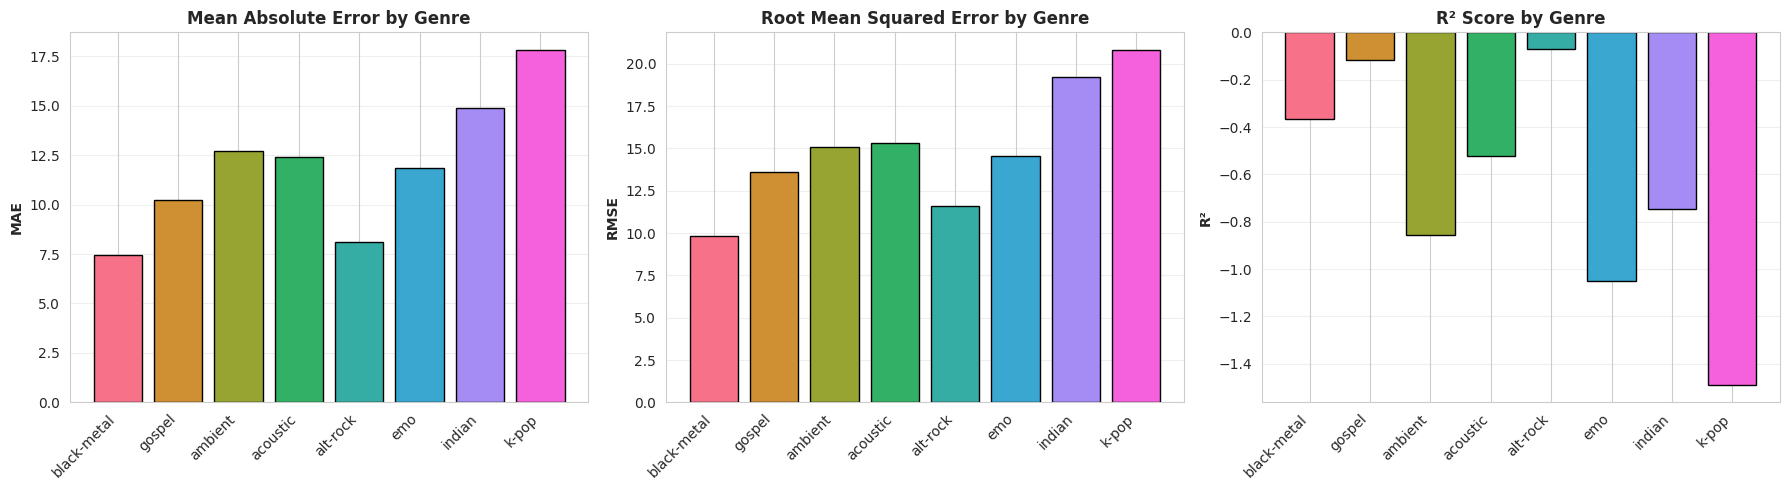


3. TRAINING GENRE-SPECIFIC CLASSIFICATION MODELS

GENRE: BLACK-METAL

📊 Data:
   Train: 17,253 tracks
   Test:  4,584 tracks
   Target (is_hit):
      Train: 2 hits (0.01%)
      Test:  4 hits (0.09%)
⚠️  Skipping black-metal - too few hits in training (< 5)

GENRE: GOSPEL

📊 Data:
   Train: 17,148 tracks
   Test:  4,473 tracks
   Target (is_hit):
      Train: 172 hits (1.00%)
      Test:  195 hits (4.36%)

⚙️  Applying SMOTE...
   After SMOTE: 33,952 samples

🌳 Training Random Forest Classifier...

✓ Results:
   Accuracy:  0.9032
   Precision: 0.1766
   Recall:    0.3333
   F1-Score:  0.2309
   ROC-AUC:   0.7809

   Confusion Matrix:
      TN:  3,975 | FP:    303
      FN:    130 | TP:     65

   Top 5 Features:
      valence             : 0.1578
      duration_mins       : 0.1389
      speechiness         : 0.1319
      tempo               : 0.1158
      energy              : 0.0864
✓ Saved model: rf_classification_gospel.pkl
✓ Saved: feature_importance_clf_gospel.csv

GENRE: AMBIEN

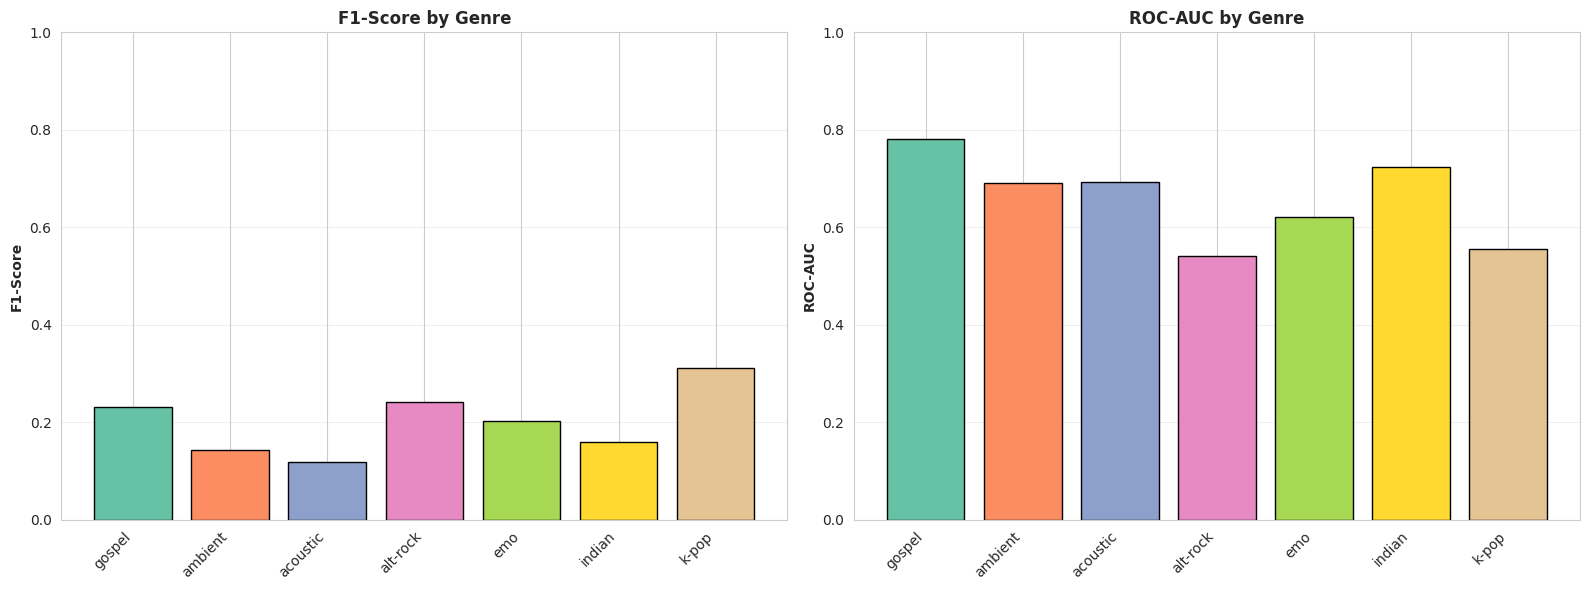


4. FEATURE IMPORTANCE COMPARISON ACROSS GENRES
✓ Saved plot: 15_feature_importance_heatmap.png


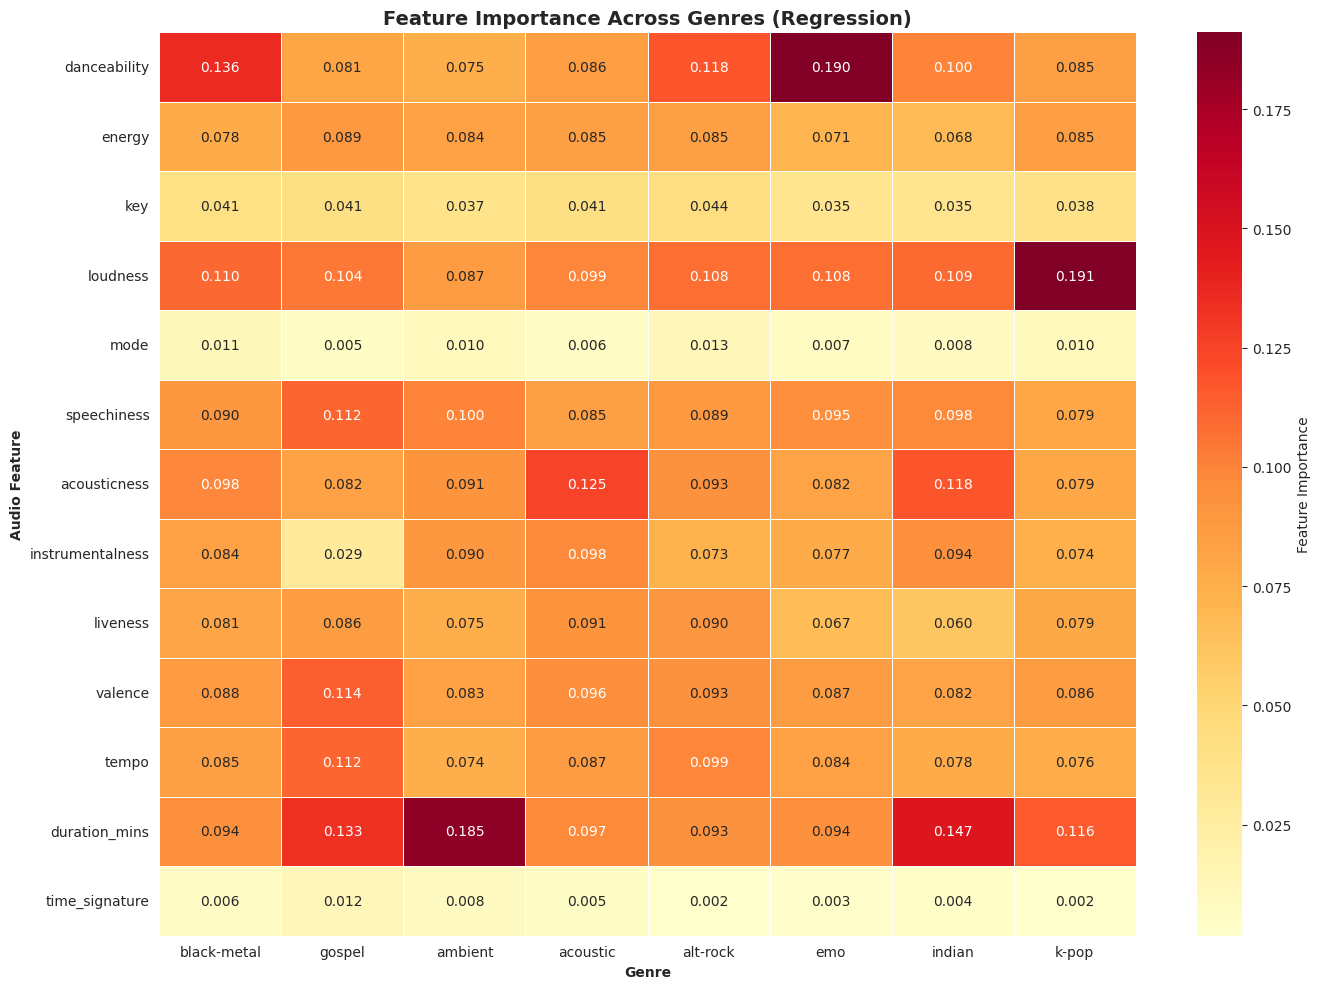

✓ Saved: feature_importance_matrix.csv

📊 Top 3 Features per Genre:

black-metal:
   danceability        : 0.1357
   loudness            : 0.1099
   acousticness        : 0.0982

gospel:
   duration_mins       : 0.1327
   valence             : 0.1136
   speechiness         : 0.1118

ambient:
   duration_mins       : 0.1851
   speechiness         : 0.1000
   acousticness        : 0.0914

acoustic:
   acousticness        : 0.1246
   loudness            : 0.0991
   instrumentalness    : 0.0975

alt-rock:
   danceability        : 0.1176
   loudness            : 0.1080
   tempo               : 0.0987

emo:
   danceability        : 0.1903
   loudness            : 0.1079
   speechiness         : 0.0953

indian:
   duration_mins       : 0.1468
   acousticness        : 0.1177
   loudness            : 0.1095

k-pop:
   loudness            : 0.1911
   duration_mins       : 0.1162
   valence             : 0.0863

SUMMARY - GENRE-SPECIFIC MODELS

📊 REGRESSION MODELS:
      Genre       MAE      RMSE

In [ ]:
"""
================================================================================
MASTER THESIS - MSc in Big Data & Business Analytics
Author: Paolina CASTANY

MUSIC SUCCESS PREDICTION: GENRE-SPECIFIC VS GLOBAL MODELS

NOTEBOOK 3: GENRE-SPECIFIC MODELS TRAINING
================================================================================
This notebook trains separate models for EACH genre:
1. Genre-specific regression models
2. Genre-specific classification models
3. Feature importance per genre
4. Cross-genre comparison
================================================================================
"""

# ============================================================================
# SETUP
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                            accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*80)
print("GENRE-SPECIFIC MODELS TRAINING")
print("="*80)
print(f"Author: Paolina CASTANY")
print(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}")
print("="*80)

# Load folder paths
with open('/content/folders.pkl', 'rb') as f:
    FOLDERS = pickle.load(f)

DATA_FOLDER = FOLDERS['data']
PLOTS_FOLDER = FOLDERS['plots']
MODELS_FOLDER = FOLDERS['models']
RESULTS_FOLDER = FOLDERS['results']

def save_plot(filename):
    filepath = os.path.join(PLOTS_FOLDER, filename)
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"✓ Saved plot: {filename}")

def save_data(df, filename):
    filepath = os.path.join(RESULTS_FOLDER, filename)
    df.to_csv(filepath, index=False)
    print(f"✓ Saved: {filename}")

def save_model(model, filename):
    filepath = os.path.join(MODELS_FOLDER, filename)
    with open(filepath, 'wb') as f:
        pickle.dump(model, f)
    print(f"✓ Saved model: {filename}")

# ============================================================================
# 1. LOAD DATA
# ============================================================================
print("\n" + "="*80)
print("1. LOADING DATA")
print("="*80)

df_train = pd.read_csv(os.path.join(DATA_FOLDER, 'spotify_train.csv'))
df_test = pd.read_csv(os.path.join(DATA_FOLDER, 'spotify_test.csv'))
feature_names = pd.read_csv(os.path.join(DATA_FOLDER, 'feature_names.csv'))['feature'].tolist()
selected_genres = pd.read_csv(os.path.join(DATA_FOLDER, 'selected_genres.csv'))['genre'].tolist()

print(f"\n✓ Data loaded:")
print(f"   Train: {len(df_train):,} tracks")
print(f"   Test: {len(df_test):,} tracks")
print(f"   Features: {len(feature_names)}")
print(f"   Genres: {len(selected_genres)}")
print(f"\n   Selected genres: {', '.join(selected_genres)}")

# ============================================================================
# 2. GENRE-SPECIFIC REGRESSION MODELS
# ============================================================================
print("\n" + "="*80)
print("2. TRAINING GENRE-SPECIFIC REGRESSION MODELS")
print("="*80)

regression_results = []
regression_models = {}
regression_scalers = {}
regression_feature_importance = {}

for genre in selected_genres:
    print(f"\n{'='*80}")
    print(f"GENRE: {genre.upper()}")
    print(f"{'='*80}")

    # Filter data
    train_genre = df_train[df_train['genre'] == genre].copy()
    test_genre = df_test[df_test['genre'] == genre].copy()

    print(f"\n📊 Data:")
    print(f"   Train: {len(train_genre):,} tracks")
    print(f"   Test:  {len(test_genre):,} tracks")

    if len(test_genre) < 50:
        print(f"⚠️  Skipping {genre} - insufficient test data (< 50 samples)")
        continue

    # Prepare data
    X_train = train_genre[feature_names]
    X_test = test_genre[feature_names]
    y_train = train_genre['popularity']
    y_test = test_genre['popularity']

    print(f"   Popularity:")
    print(f"      Train - Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
    print(f"      Test  - Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    regression_scalers[genre] = scaler

    # Train Random Forest
    print(f"\n🌳 Training Random Forest Regressor...")
    rf_reg = RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    rf_reg.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = rf_reg.predict(X_test_scaled)

    # Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n✓ Results:")
    print(f"   MAE:  {mae:.4f}")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   R²:   {r2:.4f}")

    # Feature importance
    importance = pd.DataFrame({
        'feature': feature_names,
        'importance': rf_reg.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"\n   Top 5 Features:")
    for idx, row in importance.head(5).iterrows():
        print(f"      {row['feature']:20s}: {row['importance']:.4f}")

    # Save results
    regression_results.append({
        'Genre': genre,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Train_Size': len(train_genre),
        'Test_Size': len(test_genre)
    })

    regression_models[genre] = rf_reg
    regression_feature_importance[genre] = importance

    # Save individual model and importance
    model_filename = f"rf_regression_{genre.replace(' ', '_').replace('-', '_')}.pkl"
    save_model(rf_reg, model_filename)

    importance_filename = f"feature_importance_reg_{genre.replace(' ', '_').replace('-', '_')}.csv"
    save_data(importance, importance_filename)

# Save all regression results
regression_results_df = pd.DataFrame(regression_results)
save_data(regression_results_df, 'genre_specific_regression_results.csv')

# Save scalers
with open(os.path.join(MODELS_FOLDER, 'genre_regression_scalers.pkl'), 'wb') as f:
    pickle.dump(regression_scalers, f)
print("\n✓ Saved: genre_regression_scalers.pkl")

# Summary
print("\n" + "="*80)
print("REGRESSION RESULTS SUMMARY")
print("="*80)
print(regression_results_df.to_string(index=False))

# VISUALIZATION 1: Regression Performance by Genre
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

genres = regression_results_df['Genre'].values
mae_values = regression_results_df['MAE'].values
rmse_values = regression_results_df['RMSE'].values
r2_values = regression_results_df['R2'].values

colors = sns.color_palette("husl", len(genres))

# MAE
axes[0].bar(range(len(genres)), mae_values, color=colors, edgecolor='black')
axes[0].set_xticks(range(len(genres)))
axes[0].set_xticklabels(genres, rotation=45, ha='right')
axes[0].set_ylabel('MAE', fontweight='bold')
axes[0].set_title('Mean Absolute Error by Genre', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# RMSE
axes[1].bar(range(len(genres)), rmse_values, color=colors, edgecolor='black')
axes[1].set_xticks(range(len(genres)))
axes[1].set_xticklabels(genres, rotation=45, ha='right')
axes[1].set_ylabel('RMSE', fontweight='bold')
axes[1].set_title('Root Mean Squared Error by Genre', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# R²
axes[2].bar(range(len(genres)), r2_values, color=colors, edgecolor='black')
axes[2].set_xticks(range(len(genres)))
axes[2].set_xticklabels(genres, rotation=45, ha='right')
axes[2].set_ylabel('R²', fontweight='bold')
axes[2].set_title('R² Score by Genre', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
save_plot('13_genre_regression_performance.png')
plt.show()

# ============================================================================
# 3. GENRE-SPECIFIC CLASSIFICATION MODELS
# ============================================================================
print("\n" + "="*80)
print("3. TRAINING GENRE-SPECIFIC CLASSIFICATION MODELS")
print("="*80)

classification_results = []
classification_models = {}
classification_scalers = {}
classification_feature_importance = {}

for genre in selected_genres:
    print(f"\n{'='*80}")
    print(f"GENRE: {genre.upper()}")
    print(f"{'='*80}")

    # Filter data
    train_genre = df_train[df_train['genre'] == genre].copy()
    test_genre = df_test[df_test['genre'] == genre].copy()

    print(f"\n📊 Data:")
    print(f"   Train: {len(train_genre):,} tracks")
    print(f"   Test:  {len(test_genre):,} tracks")

    if len(test_genre) < 50:
        print(f"⚠️  Skipping {genre} - insufficient test data")
        continue

    # Prepare data
    X_train = train_genre[feature_names]
    X_test = test_genre[feature_names]
    y_train = train_genre['is_hit']
    y_test = test_genre['is_hit']

    train_hit_count = y_train.sum()
    test_hit_count = y_test.sum()
    train_hit_rate = y_train.mean() * 100
    test_hit_rate = y_test.mean() * 100

    print(f"   Target (is_hit):")
    print(f"      Train: {train_hit_count} hits ({train_hit_rate:.2f}%)")
    print(f"      Test:  {test_hit_count} hits ({test_hit_rate:.2f}%)")

    # Check if enough hits
    if train_hit_count < 5:
        print(f"⚠️  Skipping {genre} - too few hits in training (< 5)")
        continue

    if test_hit_count < 2:
        print(f"⚠️  Skipping {genre} - too few hits in test (< 2)")
        continue

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    classification_scalers[genre] = scaler

    # Apply SMOTE if possible
    if train_hit_count >= 6:
        print(f"\n⚙️  Applying SMOTE...")
        try:
            smote = SMOTE(random_state=42, k_neighbors=min(5, train_hit_count-1))
            X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
            print(f"   After SMOTE: {len(y_train_smote):,} samples")
        except Exception as e:
            print(f"   SMOTE failed: {e}")
            X_train_smote = X_train_scaled
            y_train_smote = y_train
    else:
        print(f"\n⚙️  Using class weights (insufficient data for SMOTE)")
        X_train_smote = X_train_scaled
        y_train_smote = y_train

    # Train Random Forest Classifier
    print(f"\n🌳 Training Random Forest Classifier...")
    rf_clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    rf_clf.fit(X_train_smote, y_train_smote)

    # Predictions
    y_pred = rf_clf.predict(X_test_scaled)

    # Handle predict_proba
    try:
        y_prob_all = rf_clf.predict_proba(X_test_scaled)
        if y_prob_all.shape[1] == 2:
            y_prob = y_prob_all[:, 1]
        else:
            print(f"   ⚠️  Model learned only one class")
            y_prob = np.zeros(len(y_test))
    except Exception as e:
        print(f"   ⚠️  predict_proba failed: {e}")
        y_prob = np.zeros(len(y_test))

    # Evaluation
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # ROC-AUC
    try:
        if len(np.unique(y_test)) > 1 and len(np.unique(y_prob)) > 1:
            roc_auc = roc_auc_score(y_test, y_prob)
        else:
            roc_auc = 0.0
    except:
        roc_auc = 0.0

    print(f"\n✓ Results:")
    print(f"   Accuracy:  {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall:    {rec:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   ROC-AUC:   {roc_auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    if cm.shape[0] == 2 and cm.shape[1] == 2:
        print(f"\n   Confusion Matrix:")
        print(f"      TN: {cm[0,0]:6,} | FP: {cm[0,1]:6,}")
        print(f"      FN: {cm[1,0]:6,} | TP: {cm[1,1]:6,}")

    # Feature importance
    importance = pd.DataFrame({
        'feature': feature_names,
        'importance': rf_clf.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"\n   Top 5 Features:")
    for idx, row in importance.head(5).iterrows():
        print(f"      {row['feature']:20s}: {row['importance']:.4f}")

    # Save results
    classification_results.append({
        'Genre': genre,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC_AUC': roc_auc,
        'Train_Size': len(train_genre),
        'Test_Size': len(test_genre),
        'Train_Hits': train_hit_count,
        'Test_Hits': test_hit_count
    })

    classification_models[genre] = rf_clf
    classification_feature_importance[genre] = importance

    model_filename = f"rf_classification_{genre.replace(' ', '_').replace('-', '_')}.pkl"
    save_model(rf_clf, model_filename)

    importance_filename = f"feature_importance_clf_{genre.replace(' ', '_').replace('-', '_')}.csv"
    save_data(importance, importance_filename)

# Save classification results
if len(classification_results) > 0:
    classification_results_df = pd.DataFrame(classification_results)
    save_data(classification_results_df, 'genre_specific_classification_results.csv')

    # Save scalers
    with open(os.path.join(MODELS_FOLDER, 'genre_classification_scalers.pkl'), 'wb') as f:
        pickle.dump(classification_scalers, f)
    print("\n✓ Saved: genre_classification_scalers.pkl")

    # Summary
    print("\n" + "="*80)
    print("CLASSIFICATION RESULTS SUMMARY")
    print("="*80)
    print(classification_results_df.to_string(index=False))

    # VISUALIZATION 2: Classification Performance by Genre
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    genres_clf = classification_results_df['Genre'].values
    f1_values = classification_results_df['F1'].values
    roc_values = classification_results_df['ROC_AUC'].values

    colors_clf = sns.color_palette("Set2", len(genres_clf))

    # F1-Score
    axes[0].bar(range(len(genres_clf)), f1_values, color=colors_clf, edgecolor='black')
    axes[0].set_xticks(range(len(genres_clf)))
    axes[0].set_xticklabels(genres_clf, rotation=45, ha='right')
    axes[0].set_ylabel('F1-Score', fontweight='bold')
    axes[0].set_title('F1-Score by Genre', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_ylim(0, 1)

    # ROC-AUC
    axes[1].bar(range(len(genres_clf)), roc_values, color=colors_clf, edgecolor='black')
    axes[1].set_xticks(range(len(genres_clf)))
    axes[1].set_xticklabels(genres_clf, rotation=45, ha='right')
    axes[1].set_ylabel('ROC-AUC', fontweight='bold')
    axes[1].set_title('ROC-AUC by Genre', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    save_plot('14_genre_classification_performance.png')
    plt.show()
else:
    print("\n⚠️  No classification models trained (insufficient hits)")
    classification_results_df = pd.DataFrame()

# ============================================================================
# 4. FEATURE IMPORTANCE HEATMAP
# ============================================================================
print("\n" + "="*80)
print("4. FEATURE IMPORTANCE COMPARISON ACROSS GENRES")
print("="*80)

# Create importance matrix for regression
importance_matrix = pd.DataFrame(index=feature_names, columns=selected_genres)

for genre in selected_genres:
    if genre in regression_feature_importance:
        imp_df = regression_feature_importance[genre]
        for _, row in imp_df.iterrows():
            importance_matrix.loc[row['feature'], genre] = row['importance']

importance_matrix = importance_matrix.astype(float)

# VISUALIZATION 3: Feature Importance Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(importance_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            cbar_kws={'label': 'Feature Importance'}, linewidths=0.5)
plt.title('Feature Importance Across Genres (Regression)',
          fontsize=14, fontweight='bold')
plt.xlabel('Genre', fontweight='bold')
plt.ylabel('Audio Feature', fontweight='bold')
plt.tight_layout()
save_plot('15_feature_importance_heatmap.png')
plt.show()

save_data(importance_matrix, 'feature_importance_matrix.csv')

# Print top features per genre
print("\n📊 Top 3 Features per Genre:")
for genre in selected_genres:
    if genre in regression_feature_importance:
        top3 = regression_feature_importance[genre].head(3)
        print(f"\n{genre}:")
        for idx, row in top3.iterrows():
            print(f"   {row['feature']:20s}: {row['importance']:.4f}")

# ============================================================================
# 5. SUMMARY
# ============================================================================
print("\n" + "="*80)
print("SUMMARY - GENRE-SPECIFIC MODELS")
print("="*80)

print("\n📊 REGRESSION MODELS:")
print(regression_results_df.to_string(index=False))

if len(classification_results_df) > 0:
    print("\n\n📊 CLASSIFICATION MODELS:")
    print(classification_results_df.to_string(index=False))

print("\n\n✅ GENRE-SPECIFIC MODELS TRAINING COMPLETE!")
print(f"\n📁 Saved files:")
print(f"   Regression models: {len(regression_models)}")
print(f"   Classification models: {len(classification_models)}")
print(f"   Results: {RESULTS_FOLDER}")
print(f"   Plots: 3 visualizations")

print("\n" + "="*80)
print("NEXT STEP: Run Notebook 4 - Comparison & Analysis")
print("="*80)